In [17]:
import pandas as pd               # For loading and handling data
import matplotlib.pyplot as plt   # For visualizations
import numpy as np                # For numerical operations (optional)
from sklearn.cluster import KMeans        # For K-Means clustering
from sklearn.preprocessing import StandardScaler  # For data standardization

In [18]:
# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# Display first few rows to check
print("First 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [14]:
# Show column names
print("\nColumn names:")
print(df.columns.tolist())

# Show basic info about the dataset
print("\nDataset info:")
print(df.info())


Column names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
 5   Cluster                 200 non-null    int32 
dtypes: int32(1), int64(4), object(1)
memory usage: 8.7+ KB
None


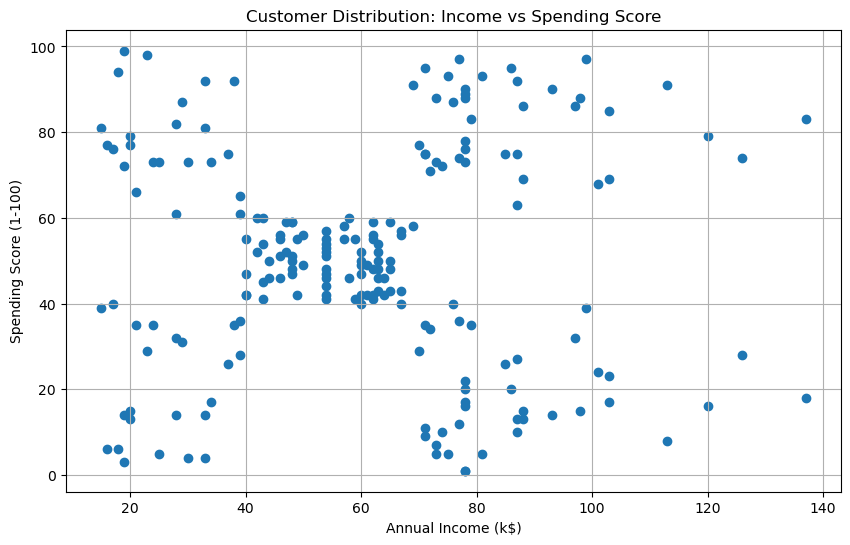

In [15]:
# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Distribution: Income vs Spending Score')
plt.grid(True)
plt.show()

In [12]:
# Select the two features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("Selected features shape:", X.shape)
print("First 5 rows of selected data:")
print(X.head())


Selected features shape: (200, 2)
First 5 rows of selected data:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [6]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier viewing (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=['Annual_Income_Standardized', 'Spending_Score_Standardized'])

print("First 5 rows of standardized data:")
print(X_scaled_df.head())

First 5 rows of standardized data:
   Annual_Income_Standardized  Spending_Score_Standardized
0                   -1.738999                    -0.434801
1                   -1.738999                     1.195704
2                   -1.700830                    -1.715913
3                   -1.700830                     1.040418
4                   -1.662660                    -0.395980


In [7]:
# Create K-Means model with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit the model and predict cluster labels
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Display the cluster centers (in original scale)
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

print("Cluster centers (original scale):")
for i, center in enumerate(cluster_centers_original):
    print(f"Cluster {i}: Income = {center[0]:.2f}, Spending Score = {center[1]:.2f}")

# Show how many customers are in each cluster
print("\nCustomer count per cluster:")
print(df['Cluster'].value_counts().sort_index())

Cluster centers (original scale):
Cluster 0: Income = 55.30, Spending Score = 49.52
Cluster 1: Income = 86.54, Spending Score = 82.13
Cluster 2: Income = 25.73, Spending Score = 79.36
Cluster 3: Income = 88.20, Spending Score = 17.11
Cluster 4: Income = 26.30, Spending Score = 20.91

Customer count per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


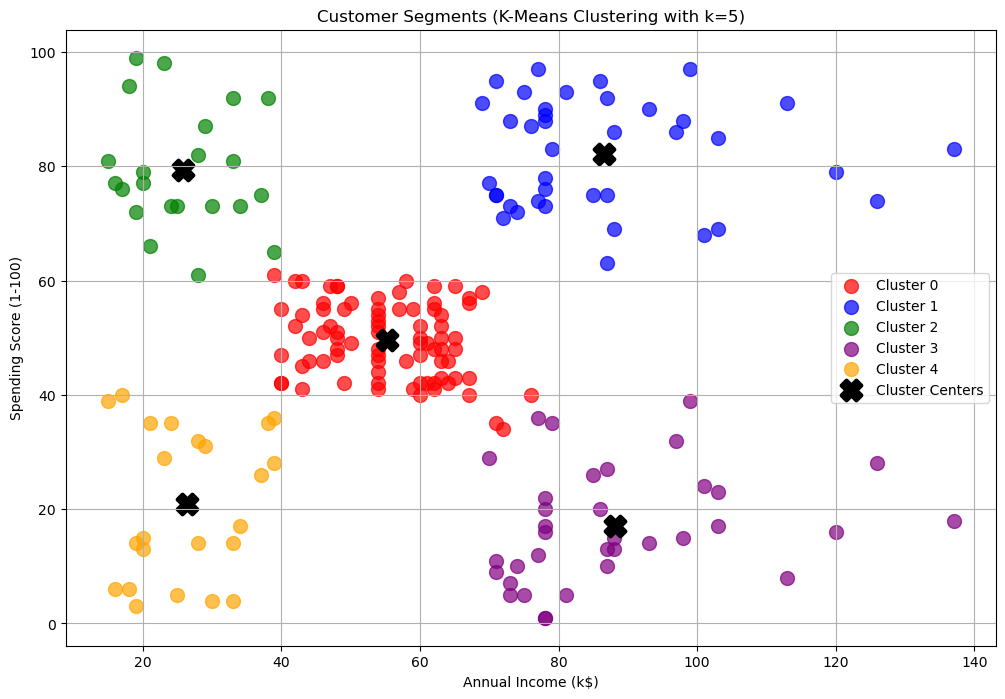

In [13]:
# Create scatter plot with different colors for each cluster
plt.figure(figsize=(12, 8))

# Define colors for 5 clusters
colors = ['red', 'blue', 'green', 'purple', 'orange']

for cluster_id in range(5):
    cluster_data = df[df['Cluster'] == cluster_id]
    plt.scatter(cluster_data['Annual Income (k$)'], 
                cluster_data['Spending Score (1-100)'],
                color=colors[cluster_id], 
                label=f'Cluster {cluster_id}',
                s=100, alpha=0.7)

# Plot cluster centers
plt.scatter(cluster_centers_original[:, 0], cluster_centers_original[:, 1],
            color='black', marker='X', s=200, linewidths=3, label='Cluster Centers')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (K-Means Clustering with k=5)')
plt.legend()
plt.grid(True)
plt.show()